#  Answer to Section 1 (-2 if not provided) (answer in one cell): 

Lighting suppliers across Australia offer a huge selection of products such as traditional fixtures to modern LED. According Expert Market Research (2025), in 2024, Australian lighting industry worth AUD12.45 billion, showing a significant growth which is driven by the increase of sustainable and efficient energy. The market is estimated to grow with a compound annual growth rate of 8.5% until 2034. This rate will expand the market size to AUD28.15 billion. This expansion is primarily due to the extensive uses of energy-efficient lighting technologies in residential, commercial, and industrial.

Reference: <br>
Expert Market Research (Claight Corporation). (2025). Australia Lighting Market Outlook - forecast trends, market size, share and Growth Analysis Report (2025-2034). PR. https://www.expertmarketresearch.com.au/reports/australia-lighting-market/toc#toc-div 

# Answer to Section 2: EDA (20 Marks) - add as many cell as needed 

In [1]:
#Import pandas function to work on the dataset, reading, cleaning
import pandas as pd

#Import matplotlib function for plotting library
import matplotlib.pyplot as plt

#Import seaborn for higher level of plotting
import seaborn as sns

#Import numpy to use for math calculation
import numpy as np

#Import scipy for calculating statistical function
from scipy import stats

In [2]:
#load data into a DataFrame by using pandas
assessment = pd.read_excel("Assessment 01.xlsx")

# Display the DataFrame with 1 row only
assessment.head(1)

# DATA CLEANING

In [3]:
#Display a summary of the dataframe, including the range index, dtypes, column headers, and memory usage
assessment.info()

In [4]:
#Convert the data in sales column to numeric value
assessment['sales']=pd.to_numeric(assessment['sales'], errors='coerce')

In [5]:
#Display the summary of the dataframe
assessment.info()

In [6]:
#Finding missing values and sum the values to get total amount
assessment.isnull().sum()

In [7]:
#Filter the DataFrame only to include rows with at least one missing value.
row_miss = assessment[assessment.isna().any(axis=1)]
row_miss 

In [8]:
#Filter the DataFrame only to include rows with missing value up to 4.
assessment = assessment[assessment.isnull().sum(axis=1) < 5]

In [9]:
#Showing the dataframe with missing value per row after flitering in cell 8
row_miss = assessment[assessment.isna().any(axis=1)]
row_miss 

In [10]:
#Dropping any duplicated value from the dataframe.
assessment = assessment.drop_duplicates()

In [11]:
#Count missing values and sum the values to get total amount after filtering
assessment.isnull().sum()

In [13]:
#Display the summary of the dataframe
assessment.info()

In [14]:
#Define and count the missing values and sum the values to get total amount
missing_values_column = assessment.isnull().sum()
print(missing_values_column)

In [15]:
#Remove the subset of missing values from the column sales_date
assessment = assessment.dropna(subset='sales_date')

##Count missing values and sum the values to check
assessment.isna().sum()

In [16]:
# Filter rows where 'item type' is either '7.0'
filtered_item_type = assessment[assessment["item_type"].isin([7.0])]
print(filtered_item_type)

In [17]:
# Filter rows where 'item type' is either '5.0'
filtered_item_type_1 = assessment[assessment["item_type"].isin([5.0])]
print(filtered_item_type_1)

In [18]:
# Get the existing value of item type description using the value of item type
item_type_description_decor = assessment.loc[assessment["item_type"] == 7.0, "item_type_description"].dropna().iloc[0]
item_type_description_decor

In [19]:
#Fill missing values with a specified value, decorative
assessment.loc[assessment["item_type"] == 7.0, "item_type_description"] = assessment.loc[assessment["item_type"] == 7.0, "item_type_description"].fillna(item_type_description_decor)

In [20]:
#Checking by showing the missing value whether it has been filled
row_miss = assessment[assessment.isna().any(axis=1)]
row_miss

In [21]:
# Get the existing value of item type description using the value of item type
item_type_description_ls = assessment.loc[assessment["item_type"] == 5.0, "item_type_description"].dropna().iloc[0]
item_type_description_ls

In [22]:
#Fill missing values with a specified value, landscape
assessment.loc[assessment["item_type"] == 5.0, "item_type_description"] = assessment.loc[assessment["item_type"] == 5.0, "item_type_description"].fillna(item_type_description_ls)

In [23]:
#Checking by showing the missing value whether it has been filled
row_miss = assessment[assessment.isna().any(axis=1)]
row_miss

In [24]:
#Count missing values and sum the values to check
assessment.isna().sum()

In [ ]:
### Grouping to find the median of sales for each item type and item type description
sales_median = assessment.groupby(['item_type','item_type_description'])['sales'].median().reset_index()
sales_median

In [26]:
# Get the sales median of the item item type 7.0 
decorative = sales_median.loc[(sales_median["item_type"] == 7.0) & (sales_median["item_type_description"] == "Decorative"), "sales"].dropna().iloc[0]
decorative

In [27]:
#Fill missing values with a specified value that defined in cell 25
assessment.loc[assessment["item_type"]== 7.0,"sales"] = assessment.loc[assessment["item_type"]== 7.0,"sales"].fillna(decorative)

In [28]:
#Checking by showing the missing value whether it has been filled
row_miss = assessment[assessment.isna().any(axis=1)]
row_miss

In [29]:
# Get the sales median of the item item type 9.0
garage = sales_median.loc[(sales_median["item_type"] == 9.0) & (sales_median["item_type_description"] == "Garage"), "sales"].dropna().iloc[0]
garage

In [30]:
#Fill missing values with a specified value that defined in cell 28
assessment.loc[assessment["item_type"]== 9.0,"sales"] = assessment.loc[assessment["item_type"]== 9.0,"sales"].fillna(garage)

In [31]:
#Checking by showing the missing value whether it has been filled
row_miss = assessment[assessment.isna().any(axis=1)]
row_miss

In [32]:
#Fill missing values in salesperson code with N/A
assessment['salesperson_code'] = assessment['salesperson_code'].fillna('N/A')

In [33]:
#Checking the missing value per row to verify all are filled
row_miss = assessment[assessment.isna().any(axis=1)]
row_miss

In [34]:
#Checking and counting all the missing value
assessment.isna().sum()

In [35]:
#Checking the unique values of the sales date column
unique_sales_date = assessment['sales_date'].unique()
print(unique_sales_date)

In [36]:
#Extracting the year, month, day from the sales_date column
#Creating new columns for sales year, month, and day
assessment['sales_year'] = assessment['sales_date'].astype(int).astype(str).str[:4]
assessment['sales_month'] = assessment['sales_date'].astype(int).astype(str).str[4:6]
assessment['sales_day'] = assessment['sales_date'].astype(int).astype(str).str[6:8]

In [37]:
# Display the DataFrame
assessment.head()

In [38]:
#Checking the unique values of the sales year
unique_sales_year = assessment['sales_year'].unique()
print(unique_sales_year)

In [39]:
#Counting the unique values of the sales year
unique_sales_year = assessment['sales_year'].value_counts()
print(unique_sales_year)

In [40]:
#Replace the wrong year, 2027 and 2028 with the correct year, 2017 and 2018
assessment.loc[assessment['sales_year'].str.contains('2027', case=False, na=False), 'sales_year'] = '2017'
assessment.loc[assessment['sales_year'].str.contains('2028', case=False, na=False), 'sales_year'] = '2018'

In [41]:
#check the changes
unique_sales_year = assessment['sales_year'].value_counts()
print(unique_sales_year)

In [42]:
#Checking the unique values of the
unique_sales_month = assessment['sales_month'].unique()
print(unique_sales_month)

In [43]:
#Checking the unique values of the sales month
unique_sales_month = assessment['sales_month'].value_counts()
print(unique_sales_month)

In [44]:
#Replace the wrong month, 22, 40  with the correct month, 12 and 04
assessment.loc[assessment['sales_month'].str.contains('22', case=False, na=False), 'sales_month'] = '12'
assessment.loc[assessment['sales_month'].str.contains('40', case=False, na=False), 'sales_month'] = '04'

In [45]:
#check the changes
unique_sales_month = assessment['sales_month'].value_counts()
print(unique_sales_month)

In [46]:
#Checking the unique values of the sales day
unique_sales_day = assessment['sales_day'].unique()
print(unique_sales_day)

In [47]:
#Checking the unique values of the customer district code
unique_cdc = assessment['customer_district_code'].unique()
print(unique_cdc) 

In [48]:
#Checking the unique values of the item type
unique_it = assessment['item_type'].unique()
print(unique_it)

In [49]:
#Checking the unique values of the item type description
unique_itd = assessment['item_type_description'].unique()
print(unique_itd) 

In [50]:
#changing the columns name of busines chain
assessment.rename(columns={'business_chain_l1_name': 'business_chain_name'}, inplace=True)
assessment.head(1)

In [51]:
#Checking the unique values of the business chain name
unique_bcn = assessment['business_chain_name'].unique()
print(unique_bcn) 

In [52]:
#Replace the spelling errors with the correct entries
assessment.loc[assessment['business_chain_name'].str.contains('NextGen Electrical Solutions', case=False, na=False), 'business_chain_name'] = 'Next Gen Electrical Solutions'
assessment.loc[assessment['business_chain_name'].str.contains('EndUser Solutions', case=False, na=False), 'business_chain_name'] = 'End Users Solutions'
assessment.loc[assessment['business_chain_name'].str.contains('ElectraCorp Ltd', case=False, na=False), 'business_chain_name'] = 'Electra Corp Ltd'
assessment.loc[assessment['business_chain_name'].str.contains('ProLighting Specialists', case=False, na=False), 'business_chain_name'] = 'Pro Lighting Specialists'
assessment.loc[assessment['business_chain_name'].str.contains('BrightPower Solutions', case=False, na=False), 'business_chain_name'] = 'Bright Power Solutions'
assessment.loc[assessment['business_chain_name'].str.contains('InterGlobal Trading', case=False, na=False), 'business_chain_name'] = 'Inter Global Trading'
assessment.loc[assessment['business_chain_name'].str.contains('PowerHub Distribution', case=False, na=False), 'business_chain_name'] = 'Power Hub Distribution'
assessment.loc[assessment['business_chain_name'].str.contains('UtilityWorks Group', case=False, na=False), 'business_chain_name'] = 'Utility Works Group'
assessment.loc[assessment['business_chain_name'].str.contains('CetraPro Distributors', case=False, na=False), 'business_chain_name'] = 'Cetra Pro Distributors'
assessment.loc[assessment['business_chain_name'].str.contains('PowerTools Direct', case=False, na=False), 'business_chain_name'] = 'Power Tools Direct'
assessment.loc[assessment['business_chain_name'].str.contains('MitrePro Suppliers', case=False, na=False), 'business_chain_name'] = 'Mitre Pro Suppliers'
assessment.loc[assessment['business_chain_name'].str.contains('CraneCo Distribution', case=False, na=False), 'business_chain_name'] = 'Crane Co Distribution'
assessment.loc[assessment['business_chain_name'].str.contains('HeadOffice Electrical Group', case=False, na=False), 'business_chain_name'] = 'Head Office Electrical Group'
assessment.loc[assessment['business_chain_name'].str.contains('Crane Co Old Branch', case=False, na=False), 'business_chain_name'] = 'Crane Co Old Branch'
assessment.loc[assessment['business_chain_name'].str.contains('SalesPro Accounts', case=False, na=False), 'business_chain_name'] = 'Sales Pro Accounts'

In [53]:
#check the changes
unique_bcn = assessment['business_chain_name'].unique()
print(unique_bcn) 

In [54]:
#changing the columns name of the business chain code
assessment.rename(columns={'business_chain_l1_code': 'business_chain_code'}, inplace=True)
assessment.head(1)

In [55]:
#Checking the unique values of the business chain code
unique_bc_code = assessment['business_chain_code'].unique()
print(unique_bc_code) 

In [56]:
#Replace errors entries that has errors in spelling
assessment.loc[assessment['business_chain_code'].str.contains('"MED"', case=False, na=False), 'business_chain_code'] = 'MED'
assessment.loc[assessment['business_chain_code'].str.contains('GEw', case=False, na=False), 'business_chain_code'] = 'GEW'
assessment.loc[assessment['business_chain_code'].str.contains('nlg', case=False, na=False), 'business_chain_code'] = 'NLG'

In [57]:
#removing the space after the letter
assessment['business_chain_code'] = assessment['business_chain_code'].astype("string").str.strip()

In [58]:
#changing the columns name
unique_bc_code = assessment['business_chain_code'].unique()
print(unique_bc_code) 

In [59]:
#Checking the unique values of the light source
unique_light_source = assessment['light_source'].unique()
print(unique_light_source) 

In [60]:
#Group the light source that are errors in spelling
light_source_clean = ['"Traditional"', 'Traditionl', 'Tradal', 'Tradisional']

#Replace errors entries that has errors in spelling
assessment.loc[assessment['light_source'].isin(light_source_clean), 'light_source'] = 'Traditional'

#Checking the changes
unique_light_source = assessment['light_source'].unique()
print(unique_light_source)

In [61]:
#Replace errors entries that has longer name with the same meaning
assessment.loc[assessment['light_source'].str.contains('Light Emitting Diode', case=False, na=False), 'light_source'] = 'LED'

In [62]:
#Checking the changes
unique_light_source = assessment['light_source'].unique()
print(unique_light_source) 

In [63]:
#Checking the unique values of the salesperson code
unique_salesperson_code = assessment['salesperson_code'].unique()
print(unique_salesperson_code)

# Histogram, Skewness and Outliers

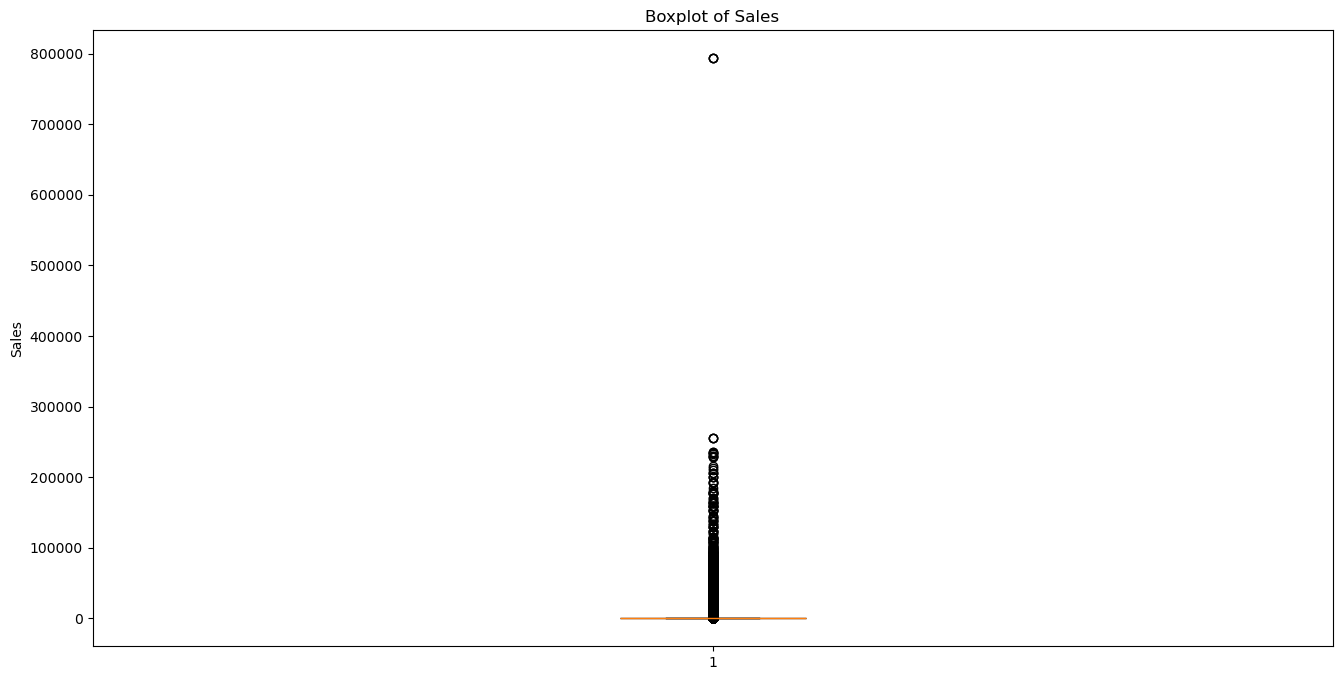

In [64]:
# Create boxplots of sales column to identify outliers
plt.figure(figsize=(16, 8))
plt.boxplot(assessment['sales'], patch_artist=True)
plt.title('Boxplot of Sales')
plt.ylabel('Sales')
plt.show()

#Show the descriptive statistics of the dataset
assessment.describe()

In [65]:
#Grouping to find the median of sales for each item type and item type description
sales_median = assessment.groupby(['item_type','item_type_description'])['sales'].median().reset_index()
sales_median

In [66]:
# Filter dataframe to show only wall mount from the item type description 
filtered_sales_wm = assessment[assessment["item_type_description"].isin(['Wall-mount'])]
filtered_sales_wm

In [67]:
#caluclate 25th percentile of wall mount
percentile25_wm = filtered_sales_wm['sales'].quantile(0.25)
print('percentile25_wm ', percentile25_wm)

#caluclate 75th percentile of wall mount
percentile75_wm = filtered_sales_wm['sales'].quantile(0.75)
print('percentile75_wm ', percentile75_wm)

In [68]:
#caluclate the median of sales of wall mount
median_sales_wm = filtered_sales_wm['sales'].median() 
print(median_sales_wm)

In [69]:
#Calculate interquartile range of wall mount
iqr_sales_wm = percentile75_wm - percentile25_wm
print(iqr_sales_wm)

#Calcualte upper and lower thresholds for outliers of wall mount
upper_limit_wm = percentile75_wm + 1.5 *iqr_sales_wm
lower_limit_wm = percentile25_wm - 1.5 *iqr_sales_wm

#Show upper and lower limit:
print ('Upper limit of wm is: ' + str(upper_limit_wm))
print ('Lower limit of wm is: ' + str(lower_limit_wm))

In [70]:
#isolate outliers lower than the lower limit of wall mount
filtered_sales_wm[filtered_sales_wm['sales'] < lower_limit_wm]

In [71]:
#isolate outliers higher than the upper limit of wall mount
df_upper_wm = filtered_sales_wm[filtered_sales_wm['sales'] > upper_limit_wm]
df_upper_wm

In [72]:
#group the upper outliers wall mount to list 
outliers_wm_upper = df_upper_wm['sales'].tolist()
outliers_wm_upper

#fix the outliers by replacing them with median of wall mount
assessment['sales'].replace(outliers_wm_upper, median_sales_wm, inplace=True)

In [73]:
# Filter dataframe to show only Industrial from the item type description 
filtered_sales_ind = assessment[assessment["item_type_description"].isin(['Industrial'])]
filtered_sales_ind

In [74]:
#caluclate 25th percentile of industrial
percentile25_ind = filtered_sales_ind['sales'].quantile(0.25)
print('percentile25_ind ', percentile25_ind)

#caluclate 75th percentile of industrial
percentile75_ind = filtered_sales_ind['sales'].quantile(0.75)
print('percentile75_ind ', percentile75_ind)

In [75]:
#caluclate the median of sales of industrial
median_sales_ind = filtered_sales_ind['sales'].median() 
print(median_sales_ind)

In [76]:
#Calculate interquartile range of industrial
iqr_sales_ind = percentile75_ind - percentile25_ind
print(iqr_sales_ind)

#Calcualte upper and lower thresholds for outliers of industrial
upper_limit_ind = percentile75_ind + 1.5 *iqr_sales_ind
lower_limit_ind = percentile25_ind - 1.5 *iqr_sales_ind

#Show upper and lower limit:
print ('Upper limit of wm is: ' + str(upper_limit_ind))
print ('Lower limit of wm is: ' + str(lower_limit_ind))

In [77]:
#isolate outliers lower than the lower limit of industrial
filtered_sales_ind[filtered_sales_ind['sales'] < lower_limit_ind]

In [78]:
#isolate outliers higher than the upper limit of industrial
df_upper_ind = filtered_sales_ind[filtered_sales_ind['sales'] > upper_limit_ind]
df_upper_ind

In [79]:
#group the upper outliers of industrial to list  
outliers_ind_upper = df_upper_ind['sales'].tolist()
outliers_ind_upper

#fix the outliers by replacing them with median of industrial
assessment['sales'].replace(outliers_ind_upper, median_sales_ind, inplace=True)

In [80]:
# Filter dataframe to show only Pendants from the item type description
filtered_sales_pd = assessment[assessment["item_type_description"].isin(['Pendants'])]
filtered_sales_pd

In [81]:
#caluclate 25th percentile of pendants
percentile25_pd = filtered_sales_pd['sales'].quantile(0.25)
print('percentile25_pd ', percentile25_pd)

#caluclate 75th percentile of pendants
percentile75_pd = filtered_sales_pd['sales'].quantile(0.75)
print('percentile75_pd ', percentile75_pd)

In [82]:
#caluclate the median of sales of pendants
median_sales_pd = filtered_sales_pd['sales'].median() 
print(median_sales_pd)

In [83]:
#Calculate interquartile range of pendants
iqr_sales_pd = percentile75_pd - percentile25_pd
print(iqr_sales_pd)

#Calcualte upper and lower thresholds for outliers of pendants
upper_limit_pd = percentile75_pd + 1.5 *iqr_sales_pd
lower_limit_pd = percentile25_pd - 1.5 *iqr_sales_pd

#Show upper and lower limit:
print ('Upper limit of pd is: ' + str(upper_limit_pd))
print ('Lower limit of pd is: ' + str(lower_limit_pd))

In [84]:
#isolate outliers lower than the lower limit of pendants
filtered_sales_pd[filtered_sales_pd['sales'] < lower_limit_pd]

In [85]:
#isolate outliers higher than the upper limit of pendants
df_upper_pd = filtered_sales_pd[filtered_sales_pd['sales'] > upper_limit_pd]
df_upper_pd

In [86]:
#group the upper outliers of pendants to list 
outliers_pd_upper = df_upper_pd['sales'].tolist()
outliers_pd_upper

#fix the outliers by replacing them with median of pendants
assessment['sales'].replace(outliers_pd_upper, median_sales_pd, inplace=True)

In [87]:
# Filter dataframe to show only Solar from the item type description
filtered_sales_sl = assessment[assessment["item_type_description"].isin(['Solar'])]
filtered_sales_sl

In [88]:
#caluclate 25th percentile of solar
percentile25_sl = filtered_sales_sl['sales'].quantile(0.25)
print('percentile25_sl ', percentile25_sl)

#caluclate 75th percentile of solar
percentile75_sl = filtered_sales_sl['sales'].quantile(0.75)
print('percentile75_sl ', percentile75_sl)

In [89]:
#caluclate the median of sales of solar
median_sales_sl = filtered_sales_sl['sales'].median() 
print(median_sales_sl)

In [90]:
#Calculate interquartile range of solar
iqr_sales_sl = percentile75_sl - percentile25_sl
print(iqr_sales_sl)

#Calcualte upper and lower thresholds for outliers of solar
upper_limit_sl = percentile75_sl + 1.5 *iqr_sales_sl
lower_limit_sl = percentile25_sl - 1.5 *iqr_sales_sl

#Show upper and lower limit:
print ('Upper limit of sl is: ' + str(upper_limit_sl))
print ('Lower limit of sl is: ' + str(lower_limit_sl))

In [91]:
#isolate outliers lower than the lower limit of solar
filtered_sales_sl[filtered_sales_sl['sales'] < lower_limit_sl]

In [92]:
#isolate outliers higher than the upper limit of solar
df_upper_sl = filtered_sales_sl[filtered_sales_sl['sales'] > upper_limit_sl]
df_upper_sl

In [93]:
#group the upper outliers of solar to list 
outliers_sl_upper = df_upper_sl['sales'].tolist()
outliers_sl_upper

#fix the outliers by replacing them with median of solar
assessment['sales'].replace(outliers_sl_upper, median_sales_sl, inplace=True)

In [94]:
# Filter dataframe to show only Healthcare from the item type description
filtered_sales_hc = assessment[assessment["item_type_description"].isin(['Healthcare'])]
filtered_sales_hc

In [95]:
#caluclate 25th percentile of healthcare
percentile25_hc = filtered_sales_hc['sales'].quantile(0.25)
print('percentile25_hc ', percentile25_hc)

#caluclate 75th percentile of healthcare
percentile75_hc = filtered_sales_hc['sales'].quantile(0.75)
print('percentile75_hc ', percentile75_hc)

In [96]:
#caluclate the median of sales of healthcare
median_sales_hc = filtered_sales_hc['sales'].median() 
print(median_sales_hc)

In [97]:
#Calculate interquartile range of healthcare
iqr_sales_hc = percentile75_hc - percentile25_hc
print(iqr_sales_hc)

#Calcualte upper and lower thresholds for outliers of healthcare
upper_limit_hc = percentile75_hc + 1.5 *iqr_sales_hc
lower_limit_hc = percentile25_hc - 1.5 *iqr_sales_hc

#Show upper and lower limit:
print ('Upper limit of hc is: ' + str(upper_limit_hc))
print ('Lower limit of hc is: ' + str(lower_limit_hc))

In [98]:
#isolate outliers lower than the lower limit of healthcare
filtered_sales_hc[filtered_sales_hc['sales'] < lower_limit_hc]

In [99]:
#isolate outliers higher than the upper limit of healthcare
df_upper_hc = filtered_sales_hc[filtered_sales_hc['sales'] > upper_limit_hc]
df_upper_hc

In [100]:
#group the upper outliers of healthcare to list 
outliers_hc_upper = df_upper_hc['sales'].tolist()
outliers_hc_upper

#fix the outliers by replacing them with median of healthcare
assessment['sales'].replace(outliers_hc_upper, median_sales_hc, inplace=True)

In [101]:
# Filter dataframe to show only Decorative from the item type description
filtered_sales_decor = assessment[assessment["item_type_description"].isin(['Decorative'])]
filtered_sales_decor

In [102]:
#caluclate 25th percentile of Decorative
percentile25_decor = filtered_sales_decor['sales'].quantile(0.25)
print('percentile25_decor ', percentile25_decor)

#caluclate 75th percentile of Decorative
percentile75_decor = filtered_sales_decor['sales'].quantile(0.75)
print('percentile75_decor ', percentile75_decor)

In [103]:
#caluclate the median of sales of Decorative
median_sales_decor = filtered_sales_decor['sales'].median() 
print(median_sales_decor)

In [104]:
#Calculate interquartile range of Decorative
iqr_sales_decor = percentile75_decor - percentile25_decor
print(iqr_sales_decor)

#Calcualte upper and lower thresholds for outliers of Decorative
upper_limit_decor = percentile75_decor + 1.5 *iqr_sales_decor
lower_limit_decor = percentile25_decor - 1.5 *iqr_sales_decor

#Show upper and lower limit:
print ('Upper limit of decor is: ' + str(upper_limit_decor))
print ('Lower limit of decor is: ' + str(lower_limit_decor))

In [105]:
#isolate outliers lower than the lower limit of Decorative
filtered_sales_decor[filtered_sales_decor['sales'] < lower_limit_decor]

In [106]:
#isolate outliers higher than the upper limit of Decorative
df_upper_decor = filtered_sales_decor[filtered_sales_decor['sales'] > upper_limit_decor]
df_upper_decor

In [107]:
#group the upper outliers of decorative to list 
outliers_decor_upper = df_upper_decor['sales'].tolist()
outliers_decor_upper

#fix the outliers by replacing them with median of Decorative
assessment['sales'].replace(outliers_decor_upper, median_sales_decor, inplace=True)

In [108]:
# Filter dataframe to show only Road-and-street from the item type description
filtered_sales_RS = assessment[assessment["item_type_description"].isin(['Road-and-street'])]
filtered_sales_RS

In [109]:
#caluclate 25th percentile of Road-and-street
percentile25_RS = filtered_sales_RS['sales'].quantile(0.25)
print('percentile25_RS ', percentile25_RS)

#caluclate 75th percentile of Road-and-street
percentile75_RS = filtered_sales_RS['sales'].quantile(0.75)
print('percentile75_RS ', percentile75_RS)

In [110]:
#caluclate the median of sales of Road-and-street
median_sales_RS = filtered_sales_RS['sales'].median() 
print(median_sales_RS)

In [111]:
#Calculate interquartile range of Road-and-street
iqr_sales_RS = percentile75_RS - percentile25_RS
print(iqr_sales_RS)

#Calcualte upper and lower thresholds for outliers of Road-and-street
upper_limit_RS = percentile75_RS + 1.5 *iqr_sales_RS
lower_limit_RS = percentile25_RS - 1.5 *iqr_sales_RS

#Show upper and lower limit:
print ('Upper limit of RS is: ' + str(upper_limit_RS))
print ('Lower limit of RS is: ' + str(lower_limit_RS))

In [112]:
#isolate outliers lower than the lower limit of Road-and-street
filtered_sales_RS[filtered_sales_RS['sales'] < lower_limit_RS]

In [113]:
#isolate outliers higher than the upper limit of Road-and-street
df_upper_RS = filtered_sales_RS[filtered_sales_RS['sales'] > upper_limit_RS]
df_upper_RS

In [114]:
#group the upper outliers of road and street to list 
outliers_RS_upper = df_upper_RS['sales'].tolist()
outliers_RS_upper

#fix the outliers by replacing them with median of Road-and-street
assessment['sales'].replace(outliers_RS_upper, median_sales_RS, inplace=True)

In [115]:
# Filter dataframe to show only Garage from the item type description
filtered_sales_g = assessment[assessment["item_type_description"].isin(['Garage'])]
filtered_sales_g

In [116]:
#caluclate 25th percentile of garage
percentile25_g = filtered_sales_g['sales'].quantile(0.25)
print('percentile25_g ', percentile25_g)

#caluclate 75th percentile of garage
percentile75_g = filtered_sales_g['sales'].quantile(0.75)
print('percentile75_g ', percentile75_g)

In [117]:
#caluclate the median of sales of garage
median_sales_g = filtered_sales_g['sales'].median() 
print(median_sales_g)

In [118]:
#Calculate interquartile range of garage
iqr_sales_g = percentile75_RS - percentile25_g
print(iqr_sales_g)

#Calcualte upper and lower thresholds for outliers of garage
upper_limit_g = percentile75_g + 1.5 *iqr_sales_g
lower_limit_g = percentile25_g - 1.5 *iqr_sales_g

#Show upper and lower limit:
print ('Upper limit of Garage is: ' + str(upper_limit_g))
print ('Lower limit of Garage is: ' + str(lower_limit_g))

In [119]:
#isolate outliers lower than the lower limit of garage
filtered_sales_g[filtered_sales_g['sales'] < lower_limit_g]

In [120]:
#isolate outliers higher than the upper limit of garage
df_upper_g = filtered_sales_g[filtered_sales_g['sales'] > upper_limit_g]
df_upper_g

In [121]:
#group the upper outliers of garage to list  
outliers_g_upper = df_upper_g['sales'].tolist()
outliers_g_upper

#fix the outliers by replacing them with median of garage
assessment['sales'].replace(outliers_g_upper, median_sales_g, inplace=True)

In [122]:
# Filter dataframe to show only Landscape from the item type description
filtered_sales_ls = assessment[assessment["item_type_description"].isin(['Landscape'])]
filtered_sales_ls

In [123]:
#caluclate 25th percentile of landscape
percentile25_ls = filtered_sales_ls['sales'].quantile(0.25)
print('percentile25_ls ', percentile25_ls)

#caluclate 75th percentile of landscape
percentile75_ls = filtered_sales_ls['sales'].quantile(0.75)
print('percentile75_ls ', percentile75_ls)

In [124]:
#Calculate interquartile range of landscape
iqr_sales_ls = percentile75_ls - percentile25_ls
print(iqr_sales_ls)

#Calcualte upper and lower thresholds for outliers of landscape
upper_limit_ls = percentile75_ls + 1.5 *iqr_sales_ls
lower_limit_ls = percentile25_ls - 1.5 *iqr_sales_ls

#Show upper and lower limit:
print ('Upper limit of ls is: ' + str(upper_limit_ls))
print ('Lower limit of ls is: ' + str(lower_limit_ls))

In [125]:
#caluclate the median of sales of landscape
median_sales_ls = filtered_sales_ls['sales'].median() 
print(median_sales_ls)

In [126]:
#isolate outliers lower than the lower limit of landscape
filtered_sales_ls[filtered_sales_ls['sales'] < lower_limit_ls]

In [127]:
#isolate outliers higher than the upper limit of landscape
df_upper_ls = filtered_sales_ls[filtered_sales_ls['sales'] > upper_limit_ls]
df_upper_ls

In [128]:
#group the upper outliers of landscape to list
outliers_ls_upper = df_upper_ls['sales'].tolist()
outliers_ls_upper

#fix the outliers by replacing them with median of landscape
assessment['sales'].replace(outliers_ls_upper, median_sales_ls, inplace=True)

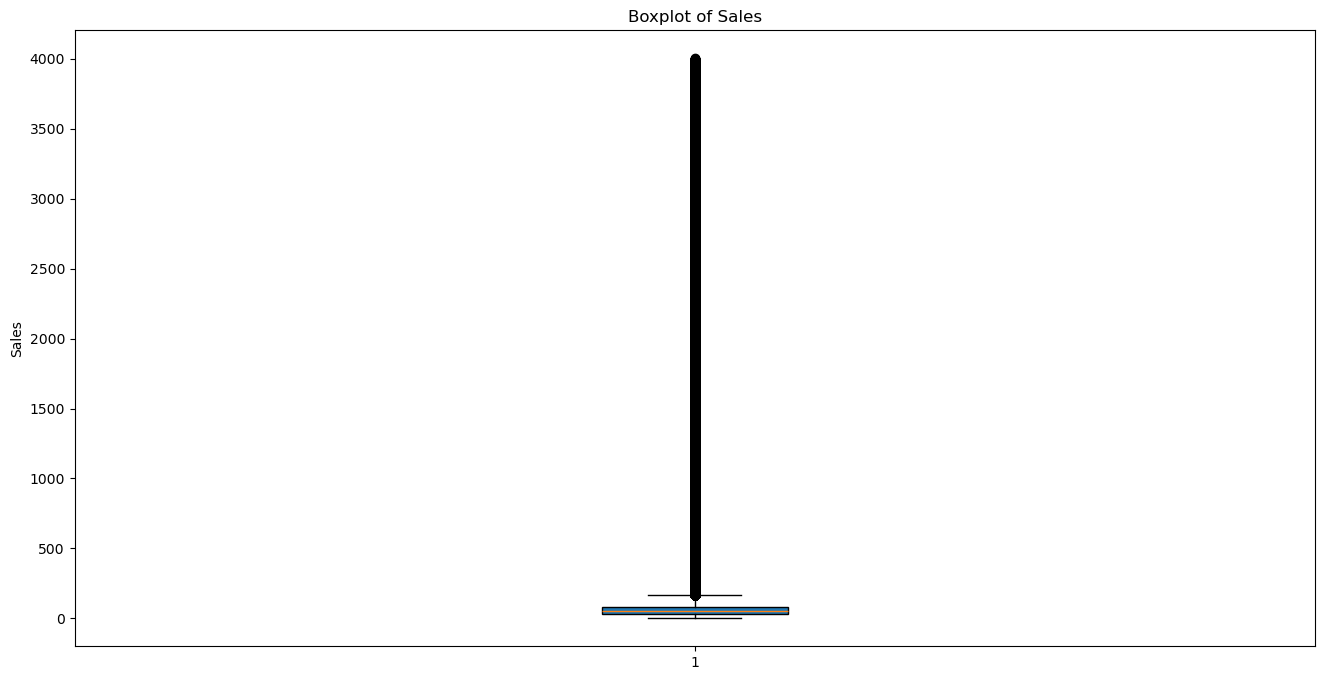

In [129]:
# Create boxplots of sales column to identify new outliers after fixing the previous outliers
plt.figure(figsize=(16, 8))

plt.boxplot(assessment['sales'], patch_artist=True)
plt.title('Boxplot of Sales')
plt.ylabel('Sales')
plt.show()

#Show the descriptive statistics of the dataset after fixing the outliers
assessment.describe()

In [130]:
# Calculating skewness before transformation
skewness_og = assessment['sales'].skew()
skewness_og

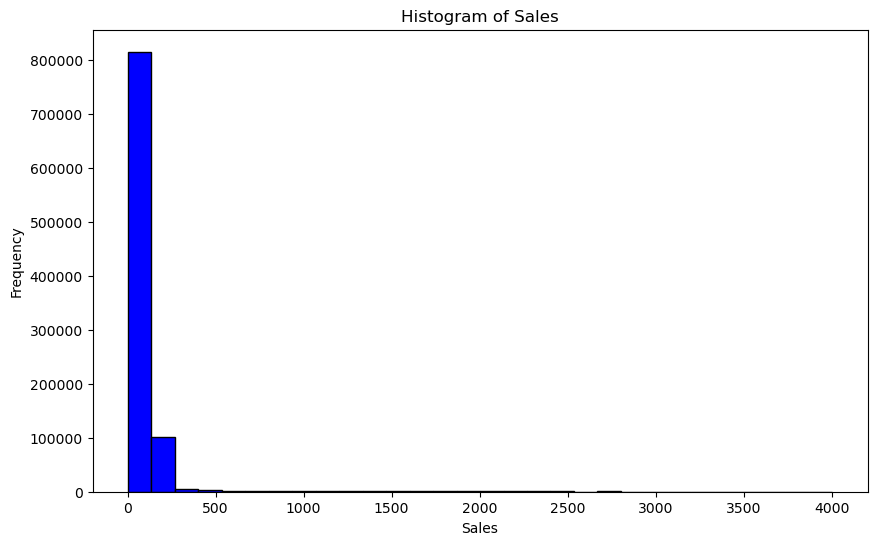

In [131]:
# Plotting Histogram to reveals how the data is distributed across the datafream, showing skewness and outliers.
plt.figure(figsize=(10, 6))
plt.hist(assessment['sales'], bins=30, color='blue', edgecolor='black')
plt.title('Histogram of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

In [132]:
# Applying log transformation to fix skewness
assessment['sales_log'] = np.log(assessment['sales'])

In [133]:
# Calculating skewness after log transformation
skewness_og_log = assessment['sales_log'].skew()
skewness_og_log

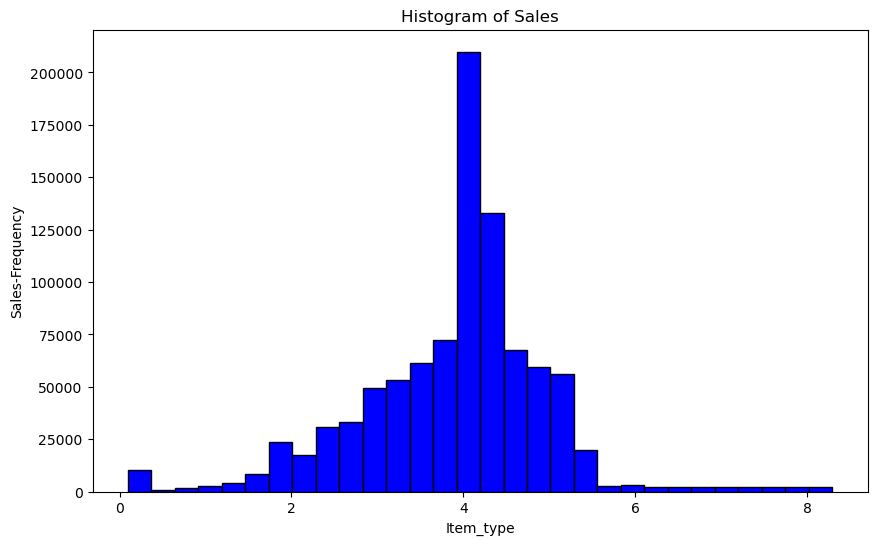

In [134]:
# Displaying histogram after log transformation
plt.figure(figsize=(10, 6))
plt.hist(assessment['sales_log'], bins=30, color='blue', edgecolor='black')
plt.title('Histogram of Sales')
plt.xlabel('Item_type')
plt.ylabel('Sales-Frequency')
plt.show()

In [135]:
#Show the descriptive statistics of the dataset after log transform
assessment.describe()

The histogram represents the distribution of the sales of lighting products. It shows a right-skewed distribution that have data clustered between item type 2 and 5. The histogram also shows that sales frequency concentrated at item type 4. The sales frequency of item 6 to 9. This shows on the long tail of the hisogram.

# Answer to Section 3: Analysis (10 Marks) - do not add any extra cells

## Visualisation 1 (all the codes in one cell) 

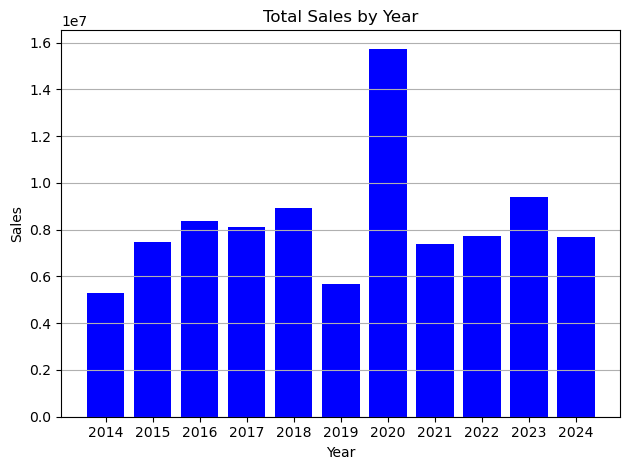

In [136]:
#Plotting the bar chart for the total sales between 2014-2024
total_sales_year = assessment.groupby('sales_year')[['sales']].sum()
print (total_sales_year)

plt.bar(total_sales_year.index, total_sales_year['sales'], color='blue')
plt.title ('Total Sales by Year')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.grid (axis='y')
plt.tight_layout()

#Showing the bar chart
plt.show()

The bar chart shows the total sales generated between the year 2014 and 2024. The chart illustrates the annual sales of lighting products remain stable between 2014 and 2019. In 2020, there was a huge increase in sales, from 6 million to almost 16 million, which is equal to more than 160% increase. This sharp rise could be triggered by factors such as internal influence and external influence. Following this huge increase, the sales dropped significantly to below 8 million. The annual sales from 2021 to 2024 remain steady around 8 million, although in 2023, there was increase from 8million to almost 10million.  Overall, the trend suggest that annual sales are generally consistent with steady pattern, however, the surge in 2020 may have been driven by the external factor, of which is the pandemic year, where there was a national lockdow.

## Visualisation 2 (all the codes in one cell) 

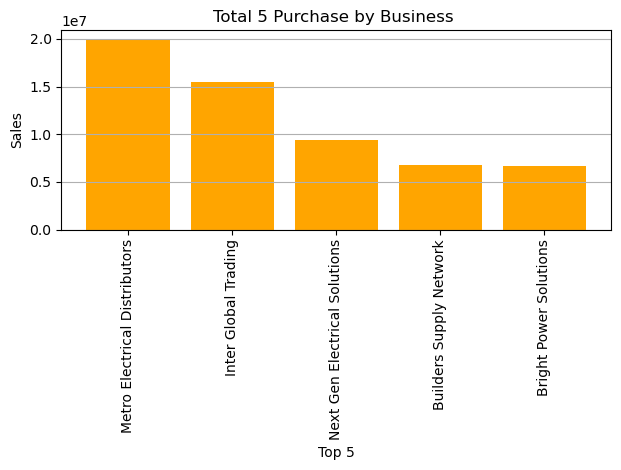

In [137]:
#Plotting the bar chart for the Top 5 Business Chain that purchase the lighting products
top_5_Business_Purchase = assessment.groupby('business_chain_name')['sales'].sum().nlargest(5)
print (top_5_Business_Purchase)

plt.bar(top_5_Business_Purchase.index, top_5_Business_Purchase, color='orange')
plt.title ('Total 5 Purchase by Business ')
plt.xlabel('Top 5')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.grid (axis='y')
plt.tight_layout()

#Showing the bar chart
plt.show()

The chart shows the five largest business that contributes to the sales between 2014 to 2024. It was shown that Metro Electrical Distributors has the highest amount of purchase reaching almost 20million in 10 years. Following this contributions, Inter Global Trading also made a combined purchased in the mount of 15 million, making them the second largest purchaser. Following Inter Global Trading is Next Gen Electrical Solutions which made total purchase in the amount of 10 million. Builders Supply Network and Bight Power Solutions share the same total purchase with just slightly over 5 million. The main insights that can be taken from these insights is the concentration of sales on 5 businesses which can be turn into opportunities to explore a stronger partnership. However, the lighting suppliers also expose to the risk of dependency on these businesses.

## Visualisation 3 (all the codes in one cell) 

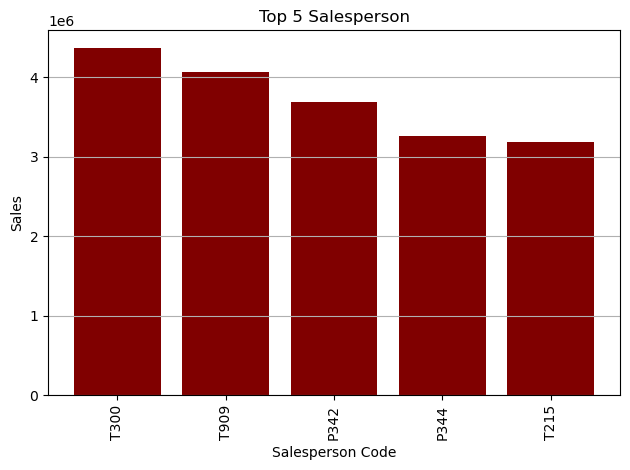

In [138]:
#Plotting the bar chart for the Top 5 Salesperson Performance
top_5_salesperson = assessment.groupby('salesperson_code')['sales'].sum().nlargest(5)
print (top_5_salesperson)

plt.bar(top_5_salesperson.index, top_5_salesperson, color='maroon')
plt.title ('Top 5 Salesperson')
plt.xlabel('Salesperson Code')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.grid (axis='y')
plt.tight_layout()

#Showing the bar chart
plt.show()

The chart illustrates the top salesperson that responsible for generating sales between 2014 and 2024. From the chart, we can see that Salesperson with code T300 achieved the highest sales, exceeding 4 million. Following T300 is T909 which the sales achievement also reaching 4 million. This indicates that there was a strong competition between T300 and T909 to achieve the highest sales. Moreover, the salesperson with code P342 generated the sales closely to 4 million. The fourth and fifth place are P344 and T215, generated total sales in the amount of around 3.2 million. From these insights, we can assume that the competition of the top salespersons is strong and indicate that their performance has contributes the most to the sales generation for the company. 

## Visualisation 4 (all the codes in one cell) 

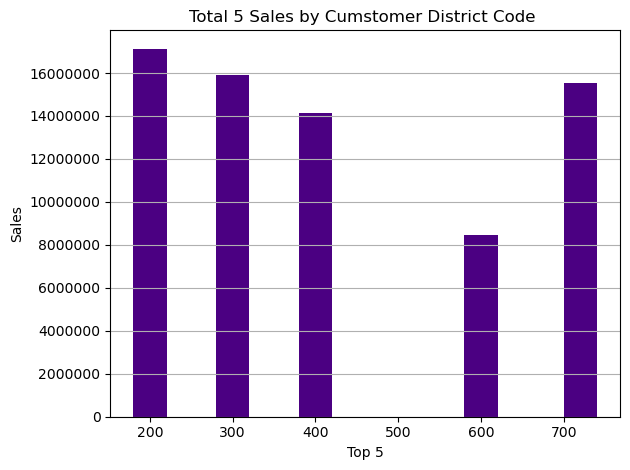

In [139]:
#Plotting the bar chart for the Top 5 Sales by Customer District Code
sales_ctm_ds_code = assessment.groupby('customer_district_code')['sales'].sum().nlargest(5)
print (sales_ctm_ds_code)

plt.bar(sales_ctm_ds_code.index, sales_ctm_ds_code, color='Indigo',width=40)

plt.title ('Total 5 Sales by Cumstomer District Code ')
plt.xlabel('Top 5')
plt.ylabel('Sales')
plt.grid (axis='y')
plt.ticklabel_format(style='plain', axis='y') 
plt.tight_layout()

#Showing the bar chart
plt.show()

The bar chart illustrates the highest sales based on customer district code. The chart shows that the customer with district code 200 has the highest contribution to sales between 2014 and 2024, exceeding the value of 16 million. The district with code 300 and 700 shares similar number of sales with each has the sales figures in the amount of over 15 million. With this amount, it has shown that the sales to customer from district code 200, 300, and 700 accumulate to almost 50 million. Additionally, the district with code 400 shows a good sales value in the amount of slightly above 14 million. In contrast, the district with code 600 shows a significant difference in terms of sales as the value only accounted for around 8.5 million, which is a 100% difference compared to district with code 200. These patterns offer valuable insights for the marketing department as this indicates that the supplying of the lighting concentrated in a few districts. Therefore, other districts that are in the supplying portfolio may require stronger marketing campaign or strong salesperson deployment to boost sales in the poor performance districts.

## Visualisation 5 (all the codes in one cell) 

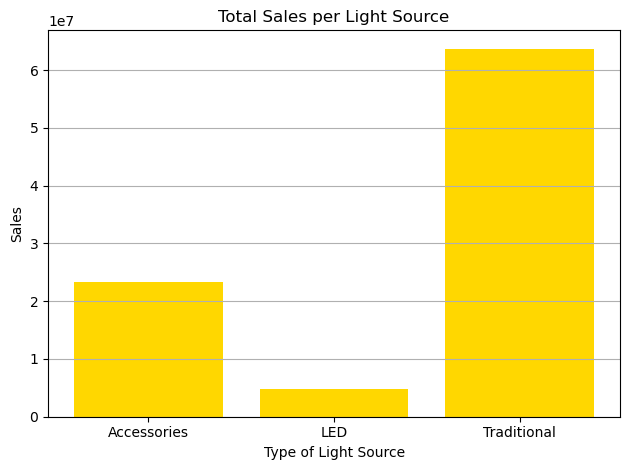

In [140]:
#Plotting the bar chart for the Total Sales by Light Source
sales_light_source = assessment.groupby('light_source')[['sales']].sum()
print (sales_light_source)

plt.bar(sales_light_source.index, sales_light_source['sales'], color='gold')
plt.title ('Total Sales per Light Source')
plt.xlabel('Type of Light Source')
plt.ylabel('Sales')
plt.grid (axis='y')
plt.tight_layout()

#Showing the bar chart
plt.show()

The bar chart shows the total revenue generated from the sales of lighting based on the source of light such as Traditional, LED, and Accessories. The chart illustrates that the traditional source has dominate the sales value over the other two sources, generated over 60 millions of sales, substantially 3 times more than the two sources combined. The lighting accessories has generated sales slightly above 20 million. Meanwhile, the LED has only contributed around 10 million to the total sales. From this chart we can gain further insight into the market of lighting by source of light. Despite, the market is growing and leaning towards energy efficient LED lighting, the traditional lightings remain the market dominant light source. However, the awareness and time lag to switch to energy efficient LED provided the opportunity for the suppliers to prepare and adopt new strategies to compete in the new trend of the lighting market.

In [141]:
assessment.to_excel('Assessment 01.xlsx', index=False)